<a href="https://colab.research.google.com/github/arthur-calado/wound-classification-ai/blob/main/wound_classification_ai_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Intelligent Home-Based Post-Surgical Wound Healing Monitoring with Computer Vision

**Author:** Arthur Bezerra Calado (abc4@cin.ufpe.br)  
**Institution:** Universidade Federal de Pernambuco - UFPE  
**Course:** Deep Learning

---

## Dataset Structure (AZH Wound Dataset)

```
Train.zip / Test.zip
├── BG/   (background - IGNORED)
├── D/    (diabetic)
├── N/    (normal - IGNORED)
├── P/    (pressure)
├── S/    (surgical)
├── V/    (venous)
```

**IMPORTANT:** Class label determined ONLY by folder name (D/P/S/V), NOT by CSV.

## Diário de Experimentos (Resumo)
- Teste inicial com MobileNetV2 → lr=1e-3 causou overfitting rápido  
- Ajuste para lr=5e-4 + mixup → melhora na validação  
- Observação: manter `shuffle=True` ajudou nos primeiros epochs  

## 1. Environment Setup and Imports

In [32]:
# Install required packages
!pip install -q albumentations

In [33]:
import os
import sys
import shutil
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path
from typing import Optional, List, Dict, Tuple
from collections import Counter
import random

# Suppress warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, backend as K
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.utils import to_categorical, Sequence

# Scikit-learn imports
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Image processing
import cv2
from PIL import Image
import glob

# Set random seeds
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("=" * 70)
print("ENVIRONMENT SETUP COMPLETE - VERSION 4 (ADVANCED)")
print("=" * 70)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print(f"NumPy version: {np.__version__}")
print("=" * 70)

ENVIRONMENT SETUP COMPLETE - VERSION 4 (ADVANCED)
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
NumPy version: 2.0.2


In [34]:
# Adicione após os imports:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

# Nova função para criar generators DenseNet:
def create_densenet_generators():
    return create_advanced_generators_generic(densenet_preprocess)

# Nova função para build:
def build_densenet_model():
    print("\n" + "=" * 70)
    print("BUILDING ADVANCED DENSENET121 MODEL")
    print("=" * 70)

    base_model = DenseNet121(
        input_shape=(Config.IMG_SIZE, Config.IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(Config.IMG_SIZE, Config.IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(Config.DENSE_UNITS_1,
                     kernel_regularizer=keras.regularizers.l2(Config.L2_REGULARIZATION),
                     kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(Config.DROPOUT_RATE)(x)

    x = layers.Dense(Config.DENSE_UNITS_2,
                     kernel_regularizer=keras.regularizers.l2(Config.L2_REGULARIZATION),
                     kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(Config.DROPOUT_RATE * 0.7)(x)

    outputs = layers.Dense(Config.NUM_CLASSES, activation='softmax',
                          kernel_initializer='glorot_uniform')(x)

    model = keras.Model(inputs, outputs, name='WoundClassifier_DenseNet121_v5')

    print(f"Model: DenseNet121 (Advanced v5)")
    print(f"Total parameters: {model.count_params():,}")

    return model, base_model

## 2. Configuration and Hyperparameters

In [35]:
class Config:
    """
    Configuration class - VERSION 4 ADVANCED.
    Optimized for achieving 80%+ accuracy.
    """

    # Dataset configuration
    IMG_SIZE = 224
    BATCH_SIZE = 16
    NUM_CLASSES = 4
    CLASS_NAMES = ['diabetic', 'pressure', 'surgical', 'venous']

    # Folder to class mapping
    FOLDER_TO_CLASS = {
        'D': 'diabetic',
        'P': 'pressure',
        'S': 'surgical',
        'V': 'venous'
    }
    IGNORE_FOLDERS = ['BG', 'N']

    # Training configuration - ADVANCED
    EPOCHS_PHASE1 = 40  # More epochs
    EPOCHS_PHASE2 = 30  # More fine-tuning
    LEARNING_RATE = 5e-4  # Slightly lower initial LR
    LEARNING_RATE_FINETUNE = 1e-6  # Very low for fine-tuning
    WARMUP_EPOCHS = 5  # NEW: Warm-up period
    EARLY_STOPPING_PATIENCE = 20  # More patience
    REDUCE_LR_PATIENCE = 7
    REDUCE_LR_FACTOR = 0.5
    MIN_LR = 1e-8

    # Data split
    VAL_SPLIT = 0.15

    # Augmentation - Conservative for medical images
    ROTATION_RANGE = 15
    WIDTH_SHIFT = 0.1
    HEIGHT_SHIFT = 0.1
    SHEAR_RANGE = 0.1
    ZOOM_RANGE = 0.1
    HORIZONTAL_FLIP = True
    VERTICAL_FLIP = False
    BRIGHTNESS_RANGE = [0.9, 1.1]

    # Model architecture - ADVANCED
    DROPOUT_RATE = 0.4  # Slightly higher
    L2_REGULARIZATION = 0.0001
    DENSE_UNITS_1 = 512
    DENSE_UNITS_2 = 256
    UNFREEZE_LAYERS = 60  # More layers

    # ADVANCED FEATURES
    USE_FOCAL_LOSS = True  # NEW
    FOCAL_GAMMA = 3.0  # NEW
    USE_MIXUP = True  # NEW
    MIXUP_ALPHA = 0.2  # NEW
    USE_TTA = True  # NEW: Test-Time Augmentation
    TTA_STEPS = 10  # NEW
    USE_ENSEMBLE = True  # NEW
    LABEL_SMOOTHING = 0.1
    OVERSAMPLE_MINORITY = True  # NEW

    # Paths
    RAW_DATA_DIR = '/content/raw_data'
    DATA_DIR = '/content/wound_dataset'
    MODEL_SAVE_DIR = '/content/models'
    RESULTS_DIR = '/content/results'
    REPO_DIR = '/content/wound-classification-repo'

    @classmethod
    def display(cls):
        print("\n" + "=" * 70)
        print("CONFIGURATION PARAMETERS (VERSION 4 - ADVANCED)")
        print("=" * 70)
        for attr in dir(cls):
            if not attr.startswith('_') and not callable(getattr(cls, attr)):
                print(f"  {attr}: {getattr(cls, attr)}")
        print("=" * 70 + "\n")


Config.display()


CONFIGURATION PARAMETERS (VERSION 4 - ADVANCED)
  BATCH_SIZE: 16
  BRIGHTNESS_RANGE: [0.9, 1.1]
  CLASS_NAMES: ['diabetic', 'pressure', 'surgical', 'venous']
  DATA_DIR: /content/wound_dataset
  DENSE_UNITS_1: 512
  DENSE_UNITS_2: 256
  DROPOUT_RATE: 0.4
  EARLY_STOPPING_PATIENCE: 20
  EPOCHS_PHASE1: 40
  EPOCHS_PHASE2: 30
  FOCAL_GAMMA: 3.0
  FOLDER_TO_CLASS: {'D': 'diabetic', 'P': 'pressure', 'S': 'surgical', 'V': 'venous'}
  HEIGHT_SHIFT: 0.1
  HORIZONTAL_FLIP: True
  IGNORE_FOLDERS: ['BG', 'N']
  IMG_SIZE: 224
  L2_REGULARIZATION: 0.0001
  LABEL_SMOOTHING: 0.1
  LEARNING_RATE: 0.0005
  LEARNING_RATE_FINETUNE: 1e-06
  MIN_LR: 1e-08
  MIXUP_ALPHA: 0.2
  MODEL_SAVE_DIR: /content/models
  NUM_CLASSES: 4
  OVERSAMPLE_MINORITY: True
  RAW_DATA_DIR: /content/raw_data
  REDUCE_LR_FACTOR: 0.5
  REDUCE_LR_PATIENCE: 7
  REPO_DIR: /content/wound-classification-repo
  RESULTS_DIR: /content/results
  ROTATION_RANGE: 15
  SHEAR_RANGE: 0.1
  TTA_STEPS: 10
  UNFREEZE_LAYERS: 60
  USE_ENSEMBLE: Tru

## 3. Focal Loss Implementation

In [36]:
class FocalLoss(keras.losses.Loss):
    """
    Focal Loss for handling class imbalance.
    Reduces the loss contribution from easy examples and focuses on hard ones.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma=2.0, alpha=None, label_smoothing=0.0, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        # Apply label smoothing
        if self.label_smoothing > 0:
            num_classes = tf.cast(tf.shape(y_true)[-1], tf.float32)
            y_true = y_true * (1.0 - self.label_smoothing) + (self.label_smoothing / num_classes)

        # Clip predictions to prevent log(0)
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())

        # Calculate cross entropy
        cross_entropy = -y_true * tf.math.log(y_pred)

        # Calculate focal weight
        focal_weight = tf.pow(1.0 - y_pred, self.gamma)

        # Apply focal weight
        focal_loss = focal_weight * cross_entropy

        # Apply class weights if provided
        if self.alpha is not None:
            alpha_tensor = tf.constant(self.alpha, dtype=tf.float32)
            focal_loss = focal_loss * alpha_tensor

        return tf.reduce_mean(tf.reduce_sum(focal_loss, axis=-1))

    def get_config(self):
        config = super().get_config()
        config.update({
            'gamma': self.gamma,
            'alpha': self.alpha,
            'label_smoothing': self.label_smoothing
        })
        return config


def get_loss_function(class_weights=None):
    """
    Get appropriate loss function based on configuration.
    """
    if Config.USE_FOCAL_LOSS:
        # Convert class weights to alpha for focal loss
        if class_weights:
            alpha = [class_weights[i] for i in range(Config.NUM_CLASSES)]
        else:
            alpha = None

        print(f"Using Focal Loss (gamma={Config.FOCAL_GAMMA}, alpha={alpha})")
        return FocalLoss(
            gamma=Config.FOCAL_GAMMA,
            alpha=alpha,
            label_smoothing=Config.LABEL_SMOOTHING
        )
    else:
        print(f"Using Categorical Crossentropy (label_smoothing={Config.LABEL_SMOOTHING})")
        return keras.losses.CategoricalCrossentropy(
            label_smoothing=Config.LABEL_SMOOTHING
        )


print("Focal Loss implementation loaded!")

Focal Loss implementation loaded!


## 4. Dataset Download and Preparation

In [37]:
def download_azh_dataset():
    """
    Download the AZH Wound Dataset from GitHub.
    """
    print("\n" + "=" * 70)
    print("DOWNLOADING AZH WOUND DATASET")
    print("=" * 70)

    repo_url = "https://github.com/uwm-bigdata/wound-classification-using-images-and-locations.git"

    if not os.path.exists(Config.REPO_DIR):
        print(f"Cloning repository...")
        !git clone {repo_url} {Config.REPO_DIR}
        print("Repository cloned!")
    else:
        print("Repository already exists.")

    print("\nRepository contents:")
    for item in os.listdir(Config.REPO_DIR):
        item_path = os.path.join(Config.REPO_DIR, item)
        size = os.path.getsize(item_path) if os.path.isfile(item_path) else "<dir>"
        print(f"  {item}: {size}")

    return Config.REPO_DIR


repo_dir = download_azh_dataset()


DOWNLOADING AZH WOUND DATASET
Repository already exists.

Repository contents:
  README.md: 1838
  BodyMap.zip: 2161760
  dataset: <dir>
  .git: <dir>


In [38]:
def prepare_wound_dataset(
    zip_or_dir: str,
    output_root: str,
    split_name: str,
    copy: bool = True,
    ignore_bg: bool = True,
    dry_run: bool = False
) -> pd.DataFrame:
    """
    Prepare the AZH wound dataset.
    """
    print(f"\n{'='*70}")
    print(f"PREPARING DATASET: {split_name.upper()}")
    print(f"{'='*70}")

    # Handle zip extraction
    if zip_or_dir.endswith('.zip'):
        extract_dir = os.path.join(Config.RAW_DATA_DIR, split_name)
        if not dry_run:
            os.makedirs(extract_dir, exist_ok=True)
            print(f"Extracting {zip_or_dir}...")
            with zipfile.ZipFile(zip_or_dir, 'r') as zf:
                zf.extractall(extract_dir)
        source_dir = extract_dir
    else:
        source_dir = zip_or_dir

    # Find data directory
    if not dry_run:
        for subdir in ['Train', 'Test', split_name.capitalize(), split_name]:
            check_path = os.path.join(source_dir, subdir)
            if os.path.exists(check_path):
                source_dir = check_path
                break

    # Create output directories
    output_split_dir = os.path.join(output_root, split_name)
    for class_name in Config.CLASS_NAMES:
        if not dry_run:
            os.makedirs(os.path.join(output_split_dir, class_name), exist_ok=True)

    # Process folders
    metadata = []
    for folder_code, class_name in Config.FOLDER_TO_CLASS.items():
        folder_path = os.path.join(source_dir, folder_code)
        if not os.path.exists(folder_path):
            continue

        image_files = []
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
            image_files.extend(glob.glob(os.path.join(folder_path, ext)))

        print(f"  {folder_code}/ ({class_name}): {len(image_files)} images")

        for img_path in image_files:
            filename = os.path.basename(img_path)
            orig_id = filename.split('_')[0] if '_' in filename else filename.split('.')[0]
            new_filename = f"{folder_code}_{filename}"
            dest_path = os.path.join(output_split_dir, class_name, new_filename)

            if not dry_run:
                shutil.copy2(img_path, dest_path)

            metadata.append({
                'split': split_name,
                'orig_folder': folder_code,
                'orig_id': orig_id,
                'orig_filename': filename,
                'new_filename': new_filename,
                'label': class_name,
                'filepath': dest_path
            })

    df_metadata = pd.DataFrame(metadata)
    print(f"\nTotal: {len(df_metadata)} images")
    if len(df_metadata) > 0:
        print(df_metadata['label'].value_counts().to_string())

    return df_metadata


def organize_full_dataset(repo_dir: str, output_root: str, dry_run: bool = False):
    """
    Organize the complete dataset.
    """
    print("\n" + "#" * 70)
    print("# ORGANIZING FULL AZH WOUND DATASET")
    print("#" * 70)

    # Find zip files
    train_zip = None
    test_zip = None

    for root, dirs, files in os.walk(repo_dir):
        for f in files:
            if f.lower() == 'train.zip':
                train_zip = os.path.join(root, f)
            elif f.lower() == 'test.zip':
                test_zip = os.path.join(root, f)

    print(f"Train zip: {train_zip}")
    print(f"Test zip: {test_zip}")

    train_metadata = pd.DataFrame()
    test_metadata = pd.DataFrame()

    if train_zip and os.path.exists(train_zip):
        train_metadata = prepare_wound_dataset(train_zip, output_root, 'train', dry_run=dry_run)

    if test_zip and os.path.exists(test_zip):
        test_metadata = prepare_wound_dataset(test_zip, output_root, 'test', dry_run=dry_run)

    # Save metadata
    all_metadata = pd.concat([train_metadata, test_metadata], ignore_index=True)
    if not dry_run and len(all_metadata) > 0:
        all_metadata.to_csv(os.path.join(output_root, 'dataset_metadata.csv'), index=False)

    print("\n" + "#" * 70)
    print("# DATASET ORGANIZATION COMPLETE")
    print("#" * 70)

    return train_metadata, test_metadata


# Organize dataset
train_metadata, test_metadata = organize_full_dataset(
    repo_dir=Config.REPO_DIR,
    output_root=Config.DATA_DIR,
    dry_run=False
)


######################################################################
# ORGANIZING FULL AZH WOUND DATASET
######################################################################
Train zip: /content/wound-classification-repo/dataset/Train.zip
Test zip: /content/wound-classification-repo/dataset/Test.zip

PREPARING DATASET: TRAIN
Extracting /content/wound-classification-repo/dataset/Train.zip...
  D/ (diabetic): 139 images
  P/ (pressure): 100 images
  S/ (surgical): 122 images
  V/ (venous): 185 images

Total: 546 images
label
venous      185
diabetic    139
surgical    122
pressure    100

PREPARING DATASET: TEST
Extracting /content/wound-classification-repo/dataset/Test.zip...
  D/ (diabetic): 46 images
  P/ (pressure): 34 images
  S/ (surgical): 42 images
  V/ (venous): 62 images

Total: 184 images
label
venous      62
diabetic    46
surgical    42
pressure    34

######################################################################
# DATASET ORGANIZATION COMPLETE
#################

## 5. Advanced Data Generator with Mixup and Oversampling

In [39]:
class AdvancedDataGenerator(Sequence):
    """
    Advanced data generator with:
    - Mixup augmentation
    - Oversampling of minority classes
    - Proper preprocessing per model
    """

    def __init__(self, dataframe, batch_size, img_size, preprocess_func,
                 augment=False, mixup=False, mixup_alpha=0.2,
                 oversample=False, shuffle=True):
        self.dataframe = dataframe.copy()
        self.batch_size = batch_size
        self.img_size = img_size
        self.preprocess_func = preprocess_func
        self.augment = augment
        self.mixup = mixup
        self.mixup_alpha = mixup_alpha
        self.oversample = oversample
        self.shuffle = shuffle
        self.class_names = Config.CLASS_NAMES
        self.n_classes = len(self.class_names)

        # Create label encoder
        self.label_to_idx = {name: idx for idx, name in enumerate(self.class_names)}

        # Oversample if needed
        if self.oversample:
            self._oversample_minority()

        self.indices = np.arange(len(self.dataframe))
        self.on_epoch_end()

    def _oversample_minority(self):
        """Oversample minority classes to balance the dataset."""
        class_counts = self.dataframe['label'].value_counts()
        max_count = class_counts.max()

        print(f"\nOversampling to balance classes (target: {max_count} per class)")

        balanced_dfs = []
        for class_name in self.class_names:
            class_df = self.dataframe[self.dataframe['label'] == class_name]
            current_count = len(class_df)

            if current_count < max_count:
                # Oversample
                oversample_count = max_count - current_count
                oversampled = class_df.sample(n=oversample_count, replace=True, random_state=SEED)
                class_df = pd.concat([class_df, oversampled], ignore_index=True)
                print(f"  {class_name}: {current_count} -> {len(class_df)}")
            else:
                print(f"  {class_name}: {current_count} (unchanged)")

            balanced_dfs.append(class_df)

        self.dataframe = pd.concat(balanced_dfs, ignore_index=True)
        print(f"  Total after oversampling: {len(self.dataframe)}")

    def __len__(self):
        return int(np.ceil(len(self.dataframe) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_df = self.dataframe.iloc[batch_indices]

        images = []
        labels = []

        for _, row in batch_df.iterrows():
            img = self._load_and_preprocess(row['filepath'])
            label = self.label_to_idx[row['label']]

            if self.augment:
                img = self._augment_image(img)

            images.append(img)
            labels.append(label)

        images = np.array(images)
        labels = to_categorical(labels, num_classes=self.n_classes)

        # Apply mixup
        if self.mixup and self.augment:
            images, labels = self._mixup_batch(images, labels)

        return images, labels

    def _load_and_preprocess(self, filepath):
        """Load and preprocess image."""
        img = cv2.imread(filepath)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = img.astype(np.float32)

        # Apply model-specific preprocessing
        img = self.preprocess_func(img)
        return img

    def _augment_image(self, img):
        """Apply augmentation to image."""
        # Random horizontal flip
        if Config.HORIZONTAL_FLIP and np.random.random() > 0.5:
            img = np.fliplr(img)

        # Random rotation
        if Config.ROTATION_RANGE > 0:
            angle = np.random.uniform(-Config.ROTATION_RANGE, Config.ROTATION_RANGE)
            M = cv2.getRotationMatrix2D((self.img_size/2, self.img_size/2), angle, 1)
            img = cv2.warpAffine(img, M, (self.img_size, self.img_size))

        # Random brightness
        if Config.BRIGHTNESS_RANGE:
            factor = np.random.uniform(Config.BRIGHTNESS_RANGE[0], Config.BRIGHTNESS_RANGE[1])
            img = img * factor
            img = np.clip(img, -1, 1) if img.min() < 0 else np.clip(img, 0, 255)

        return img

    def _mixup_batch(self, images, labels):
        """Apply mixup augmentation to batch."""
        batch_size = len(images)
        indices = np.random.permutation(batch_size)

        # Sample lambda from Beta distribution
        lam = np.random.beta(self.mixup_alpha, self.mixup_alpha)

        # Mix images and labels
        mixed_images = lam * images + (1 - lam) * images[indices]
        mixed_labels = lam * labels + (1 - lam) * labels[indices]

        return mixed_images, mixed_labels

    def on_epoch_end(self):
        """Shuffle indices at end of epoch."""
        if self.shuffle:
            np.random.shuffle(self.indices)

    @property
    def samples(self):
        return len(self.dataframe)

    @property
    def classes(self):
        return self.dataframe['label'].map(self.label_to_idx).values

    @property
    def class_indices(self):
        return self.label_to_idx

    @property
    def filepaths(self):
        return self.dataframe['filepath'].tolist()


print("AdvancedDataGenerator loaded!")

AdvancedDataGenerator loaded!


In [40]:
def compute_class_weights_from_metadata(metadata_df):
    """
    Compute class weights from metadata.
    """
    labels = metadata_df['label'].values
    label_encoder = {name: idx for idx, name in enumerate(Config.CLASS_NAMES)}
    encoded_labels = [label_encoder[l] for l in labels]

    weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(encoded_labels),
        y=encoded_labels
    )

    class_weight_dict = {i: w for i, w in enumerate(weights)}

    print("\nClass distribution and weights:")
    for idx, class_name in enumerate(Config.CLASS_NAMES):
        count = sum(1 for l in labels if l == class_name)
        print(f"  {class_name}: {count} samples, weight={class_weight_dict[idx]:.3f}")

    return class_weight_dict


def create_advanced_generators(model_type='mobilenet'):
    """
    Create advanced data generators with all optimizations.
    """
    print("\n" + "=" * 70)
    print(f"CREATING ADVANCED GENERATORS FOR {model_type.upper()}")
    print("=" * 70)

    # Select preprocessing function
    if model_type == 'mobilenet':
        preprocess_func = mobilenet_preprocess
        print("Using MobileNetV2 preprocessing")
    else:
        preprocess_func = efficientnet_preprocess
        print("Using EfficientNet preprocessing")

    # Load metadata
    train_dir = os.path.join(Config.DATA_DIR, 'train')
    test_dir = os.path.join(Config.DATA_DIR, 'test')

    # Create dataframes from directories
    train_data = []
    for class_name in Config.CLASS_NAMES:
        class_dir = os.path.join(train_dir, class_name)
        if os.path.exists(class_dir):
            for f in os.listdir(class_dir):
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    train_data.append({
                        'filepath': os.path.join(class_dir, f),
                        'label': class_name
                    })

    test_data = []
    for class_name in Config.CLASS_NAMES:
        class_dir = os.path.join(test_dir, class_name)
        if os.path.exists(class_dir):
            for f in os.listdir(class_dir):
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    test_data.append({
                        'filepath': os.path.join(class_dir, f),
                        'label': class_name
                    })

    train_df = pd.DataFrame(train_data)
    test_df = pd.DataFrame(test_data)

    # Split training into train/val
    train_df_split, val_df = train_test_split(
        train_df,
        test_size=Config.VAL_SPLIT,
        stratify=train_df['label'],
        random_state=SEED
    )

    print(f"\nTraining samples: {len(train_df_split)}")
    print(f"Validation samples: {len(val_df)}")
    print(f"Test samples: {len(test_df)}")

    # Compute class weights
    class_weights = compute_class_weights_from_metadata(train_df_split)

    # Create generators
    train_gen = AdvancedDataGenerator(
        dataframe=train_df_split,
        batch_size=Config.BATCH_SIZE,
        img_size=Config.IMG_SIZE,
        preprocess_func=preprocess_func,
        augment=True,
        mixup=Config.USE_MIXUP,
        mixup_alpha=Config.MIXUP_ALPHA,
        oversample=Config.OVERSAMPLE_MINORITY,
        shuffle=True
    )

    val_gen = AdvancedDataGenerator(
        dataframe=val_df,
        batch_size=Config.BATCH_SIZE,
        img_size=Config.IMG_SIZE,
        preprocess_func=preprocess_func,
        augment=False,
        mixup=False,
        oversample=False,
        shuffle=False
    )

    test_gen = AdvancedDataGenerator(
        dataframe=test_df,
        batch_size=Config.BATCH_SIZE,
        img_size=Config.IMG_SIZE,
        preprocess_func=preprocess_func,
        augment=False,
        mixup=False,
        oversample=False,
        shuffle=False
    )

    print(f"\nAdvanced features enabled:")
    print(f"  - Mixup: {Config.USE_MIXUP}")
    print(f"  - Oversampling: {Config.OVERSAMPLE_MINORITY}")
    print(f"  - Training batches per epoch: {len(train_gen)}")

    return train_gen, val_gen, test_gen, class_weights

## 6. Model Architecture with Advanced Features

In [41]:
def build_advanced_model(base_model_type='mobilenet'):
    """
    Build model with advanced architecture.
    """
    print("\n" + "=" * 70)
    print(f"BUILDING ADVANCED {base_model_type.upper()} MODEL")
    print("=" * 70)

    # Select base model
    if base_model_type == 'mobilenet':
        base_model = MobileNetV2(
            input_shape=(Config.IMG_SIZE, Config.IMG_SIZE, 3),
            include_top=False,
            weights='imagenet'
        )
    else:
        base_model = EfficientNetB0(
            input_shape=(Config.IMG_SIZE, Config.IMG_SIZE, 3),
            include_top=False,
            weights='imagenet'
        )

    base_model.trainable = False

    # Build model
    inputs = keras.Input(shape=(Config.IMG_SIZE, Config.IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # Advanced classification head
    x = layers.Dense(
        Config.DENSE_UNITS_1,
        kernel_regularizer=keras.regularizers.l2(Config.L2_REGULARIZATION),
        kernel_initializer='he_normal'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(Config.DROPOUT_RATE)(x)

    x = layers.Dense(
        Config.DENSE_UNITS_2,
        kernel_regularizer=keras.regularizers.l2(Config.L2_REGULARIZATION),
        kernel_initializer='he_normal'
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(Config.DROPOUT_RATE * 0.7)(x)

    outputs = layers.Dense(
        Config.NUM_CLASSES,
        activation='softmax',
        kernel_initializer='glorot_uniform'
    )(x)

    model = keras.Model(inputs, outputs, name=f'WoundClassifier_{base_model_type}_v4')

    print(f"\nModel: {base_model_type} (Advanced v4)")
    print(f"Total parameters: {model.count_params():,}")
    print(f"Trainable parameters: {sum([np.prod(w.shape) for w in model.trainable_weights]):,}")

    return model, base_model

## 7. Advanced Training with Warm-up and Cosine Annealing

In [42]:
class WarmUpCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    """
    Learning rate schedule with warm-up and cosine decay.
    """

    def __init__(self, initial_lr, warmup_steps, total_steps):
        super().__init__()
        self.initial_lr = initial_lr
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)

        # Warm-up phase
        warmup_lr = self.initial_lr * (step / self.warmup_steps)

        # Cosine decay phase
        progress = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
        cosine_lr = self.initial_lr * 0.5 * (1 + tf.cos(np.pi * progress))

        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {
            'initial_lr': self.initial_lr,
            'warmup_steps': self.warmup_steps,
            'total_steps': self.total_steps
        }


def get_advanced_callbacks(model_name, patience_mult=1.0, use_lr_schedule=False):
    """
    Create advanced callbacks.
    Note: ReduceLROnPlateau is incompatible with LearningRateSchedule.
    """
    os.makedirs(Config.MODEL_SAVE_DIR, exist_ok=True)

    callback_list = [
        callbacks.EarlyStopping(
            monitor='val_loss',
            patience=int(Config.EARLY_STOPPING_PATIENCE * patience_mult),
            restore_best_weights=True,
            verbose=1,
            min_delta=0.001
        ),
        callbacks.ModelCheckpoint(
            filepath=os.path.join(Config.MODEL_SAVE_DIR, f'{model_name}_best.keras'),
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

    # Only add ReduceLROnPlateau if NOT using a LearningRateSchedule
    if not use_lr_schedule:
        callback_list.append(
            callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=Config.REDUCE_LR_FACTOR,
                patience=Config.REDUCE_LR_PATIENCE,
                min_lr=Config.MIN_LR,
                verbose=1
            )
        )

    return callback_list


def train_advanced_model(model, base_model, train_gen, val_gen, class_weights, model_name):
    """
    Train with advanced features.
    """
    print("\n" + "=" * 70)
    print(f"TRAINING {model_name.upper()} (ADVANCED v4)")
    print("=" * 70)

    # Get loss function
    loss_fn = get_loss_function(class_weights)

    # Phase 1: Train classification head
    print("\n--- PHASE 1: Training classification head ---")
    print(f"Epochs: {Config.EPOCHS_PHASE1}")
    print(f"Learning rate: {Config.LEARNING_RATE} (with warm-up + cosine decay)")

    # Calculate steps for warm-up
    steps_per_epoch = len(train_gen)
    warmup_steps = Config.WARMUP_EPOCHS * steps_per_epoch
    total_steps = Config.EPOCHS_PHASE1 * steps_per_epoch

    # Create learning rate schedule
    lr_schedule = WarmUpCosineDecay(
        initial_lr=Config.LEARNING_RATE,
        warmup_steps=warmup_steps,
        total_steps=total_steps
    )

    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr_schedule),
        loss=loss_fn,
        metrics=['accuracy']
    )

    # Use callbacks WITHOUT ReduceLROnPlateau (incompatible with schedule)
    history1 = model.fit(
        train_gen,
        epochs=Config.EPOCHS_PHASE1,
        validation_data=val_gen,
        callbacks=get_advanced_callbacks(f'{model_name}_phase1', use_lr_schedule=True),
        class_weight=class_weights,
        verbose=1
    )

    # Phase 2: Fine-tuning
    print("\n--- PHASE 2: Fine-tuning backbone ---")

    base_model.trainable = True
    for layer in base_model.layers[:-Config.UNFREEZE_LAYERS]:
        layer.trainable = False

    trainable_count = sum([np.prod(w.shape) for w in model.trainable_weights])
    print(f"Fine-tuning last {Config.UNFREEZE_LAYERS} layers")
    print(f"Trainable parameters: {trainable_count:,}")
    print(f"Learning rate: {Config.LEARNING_RATE_FINETUNE}")

    # Phase 2: Use fixed LR (no schedule) so ReduceLROnPlateau works
    model.compile(
        optimizer=optimizers.Adam(learning_rate=Config.LEARNING_RATE_FINETUNE),
        loss=loss_fn,
        metrics=['accuracy']
    )

    # Use callbacks WITH ReduceLROnPlateau (compatible with fixed LR)
    history2 = model.fit(
        train_gen,
        epochs=Config.EPOCHS_PHASE2,
        validation_data=val_gen,
        callbacks=get_advanced_callbacks(f'{model_name}_phase2', patience_mult=0.7, use_lr_schedule=False),
        class_weight=class_weights,
        verbose=1
    )

    # Combine history
    history = {
        'loss': history1.history['loss'] + history2.history['loss'],
        'accuracy': history1.history['accuracy'] + history2.history['accuracy'],
        'val_loss': history1.history['val_loss'] + history2.history['val_loss'],
        'val_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy']
    }

    model.save(os.path.join(Config.MODEL_SAVE_DIR, f'{model_name}_final.keras'))
    print(f"\nModel saved!")

    return history

## 8. Test-Time Augmentation (TTA)

In [43]:
def predict_with_tta(model, test_gen, preprocess_func, n_augments=5):
    """
    Make predictions with Test-Time Augmentation.
    Aggregates predictions from multiple augmented versions.
    """
    print(f"\nApplying Test-Time Augmentation ({n_augments} augmentations)...")

    all_predictions = []

    # Original predictions (no augmentation)
    test_gen_original = AdvancedDataGenerator(
        dataframe=pd.DataFrame({'filepath': test_gen.filepaths, 'label': [Config.CLASS_NAMES[c] for c in test_gen.classes]}),
        batch_size=Config.BATCH_SIZE,
        img_size=Config.IMG_SIZE,
        preprocess_func=preprocess_func,
        augment=False,
        shuffle=False
    )

    preds_original = model.predict(test_gen_original, verbose=0)
    all_predictions.append(preds_original)

    # Augmented predictions
    for i in range(n_augments - 1):
        test_gen_aug = AdvancedDataGenerator(
            dataframe=pd.DataFrame({'filepath': test_gen.filepaths, 'label': [Config.CLASS_NAMES[c] for c in test_gen.classes]}),
            batch_size=Config.BATCH_SIZE,
            img_size=Config.IMG_SIZE,
            preprocess_func=preprocess_func,
            augment=True,  # Apply augmentation
            shuffle=False
        )
        preds_aug = model.predict(test_gen_aug, verbose=0)
        all_predictions.append(preds_aug)

    # Average predictions
    avg_predictions = np.mean(all_predictions, axis=0)

    print(f"TTA complete. Averaged {n_augments} predictions.")
    return avg_predictions

## 9. Evaluation Functions

In [44]:
def plot_training_history(history, model_name):
    """Plot training curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name} - Loss Curves')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{model_name} - Accuracy Curves')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    os.makedirs(Config.RESULTS_DIR, exist_ok=True)
    plt.savefig(os.path.join(Config.RESULTS_DIR, f'{model_name}_training_curves.png'), dpi=150)
    plt.show()


def evaluate_model_advanced(model, test_gen, preprocess_func, model_name, use_tta=True):
    """
    Evaluate model with optional TTA.
    """
    print("\n" + "=" * 70)
    print(f"EVALUATING {model_name.upper()}")
    print("=" * 70)

    # Get predictions
    if use_tta and Config.USE_TTA:
        y_pred_proba = predict_with_tta(model, test_gen, preprocess_func, n_augments=Config.TTA_STEPS)
    else:
        y_pred_proba = model.predict(test_gen, verbose=1)

    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = test_gen.classes
    class_names = list(test_gen.class_indices.keys())

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print("\nClassification Report:")
    print("-" * 60)
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    print("\nSummary Metrics:")
    print("-" * 60)
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    if use_tta and Config.USE_TTA:
        print(f"  (with TTA: {Config.TTA_STEPS} augmentations)")

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'class_names': class_names
    }


def plot_confusion_matrix(results, model_name):
    """Plot confusion matrix."""
    cm = confusion_matrix(results['y_true'], results['y_pred'])
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=results['class_names'],
                yticklabels=results['class_names'], ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title(f'{model_name} - Confusion Matrix (Counts)')

    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=results['class_names'],
                yticklabels=results['class_names'], ax=axes[1])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].set_title(f'{model_name} - Confusion Matrix (Normalized)')

    plt.tight_layout()
    plt.savefig(os.path.join(Config.RESULTS_DIR, f'{model_name}_confusion_matrix.png'), dpi=150)
    plt.show()


def plot_roc_curves(results, model_name):
    """Plot ROC curves."""
    n_classes = len(results['class_names'])
    y_true_binary = to_categorical(results['y_true'], num_classes=n_classes)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.Set1(np.linspace(0, 1, n_classes))

    for i, (class_name, color) in enumerate(zip(results['class_names'], colors)):
        fpr, tpr, _ = roc_curve(y_true_binary[:, i], results['y_pred_proba'][:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{class_name} (AUC = {roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_name} - ROC Curves')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(Config.RESULTS_DIR, f'{model_name}_roc_curves.png'), dpi=150)
    plt.show()

## 10. Model Ensemble

In [45]:
# Após treinar os 3 modelos, combine assim:
def ensemble_3_models(mobilenet_results, efficientnet_results, densenet_results):
    # Pesos baseados na performance individual
    accs = [mobilenet_results['accuracy'],
            efficientnet_results['accuracy'],
            densenet_results['accuracy']]
    total = sum(accs)
    weights = [a/total for a in accs]

    return ensemble_predictions(
        [mobilenet_results, efficientnet_results, densenet_results],
        weights=weights
    )

In [46]:
def _cutmix_batch(self, images, labels):
    """Apply CutMix augmentation - corta e cola regiões entre imagens."""
    batch_size = len(images)
    indices = np.random.permutation(batch_size)

    lam = np.random.beta(1.0, 1.0)

    # Calcula bounding box
    W, H = self.img_size, self.img_size
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    # Aplica CutMix
    mixed_images = images.copy()
    mixed_images[:, bby1:bby2, bbx1:bbx2, :] = images[indices, bby1:bby2, bbx1:bbx2, :]

    # Ajusta labels proporcionalmente à área cortada
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (W * H))
    mixed_labels = lam * labels + (1 - lam) * labels[indices]

    return mixed_images, mixed_labels

In [47]:
def ensemble_predictions(models_results, weights=None):
    """
    Combine predictions from multiple models.

    Args:
        models_results: List of results dictionaries from each model
        weights: Optional weights for each model (default: equal weights)

    Returns:
        Combined results dictionary
    """
    print("\n" + "=" * 70)
    print("ENSEMBLE PREDICTIONS")
    print("=" * 70)

    n_models = len(models_results)

    if weights is None:
        weights = [1.0 / n_models] * n_models

    print(f"\nCombining {n_models} models with weights: {weights}")

    # Weighted average of probabilities
    ensemble_proba = np.zeros_like(models_results[0]['y_pred_proba'])
    for i, (result, weight) in enumerate(zip(models_results, weights)):
        print(f"  - {result['model_name']}: weight={weight:.2f}, accuracy={result['accuracy']:.4f}")
        ensemble_proba += weight * result['y_pred_proba']

    ensemble_pred = np.argmax(ensemble_proba, axis=1)
    y_true = models_results[0]['y_true']
    class_names = models_results[0]['class_names']

    # Calculate ensemble metrics
    accuracy = accuracy_score(y_true, ensemble_pred)
    precision = precision_score(y_true, ensemble_pred, average='weighted')
    recall = recall_score(y_true, ensemble_pred, average='weighted')
    f1 = f1_score(y_true, ensemble_pred, average='weighted')

    print("\n" + "=" * 70)
    print("ENSEMBLE RESULTS")
    print("=" * 70)
    print(classification_report(y_true, ensemble_pred, target_names=class_names, digits=4))

    print("\nEnsemble Metrics:")
    print("-" * 60)
    print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    return {
        'model_name': 'Ensemble',
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'y_true': y_true,
        'y_pred': ensemble_pred,
        'y_pred_proba': ensemble_proba,
        'class_names': class_names
    }

## 11. Train MobileNetV2

In [48]:
# Create generators for MobileNetV2
mobilenet_train_gen, mobilenet_val_gen, mobilenet_test_gen, mobilenet_class_weights = \
    create_advanced_generators('mobilenet')


CREATING ADVANCED GENERATORS FOR MOBILENET
Using MobileNetV2 preprocessing

Training samples: 464
Validation samples: 82
Test samples: 184

Class distribution and weights:
  diabetic: 118 samples, weight=0.983
  pressure: 85 samples, weight=1.365
  surgical: 104 samples, weight=1.115
  venous: 157 samples, weight=0.739

Oversampling to balance classes (target: 157 per class)
  diabetic: 118 -> 157
  pressure: 85 -> 157
  surgical: 104 -> 157
  venous: 157 (unchanged)
  Total after oversampling: 628

Advanced features enabled:
  - Mixup: True
  - Oversampling: True
  - Training batches per epoch: 40


In [49]:
# Build MobileNetV2 model
mobilenet_model, mobilenet_base = build_advanced_model('mobilenet')


BUILDING ADVANCED MOBILENET MODEL

Model: mobilenet (Advanced v4)
Total parameters: 3,049,284
Trainable parameters: 789,764


In [50]:
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++# Train MobileNetV2
mobilenet_history = train_advanced_model(
    mobilenet_model, mobilenet_base,
    mobilenet_train_gen, mobilenet_val_gen,
    mobilenet_class_weights,
    model_name='MobileNetV2'
)


TRAINING MOBILENETV2 (ADVANCED v4)
Using Focal Loss (gamma=3.0, alpha=[np.float64(0.9830508474576272), np.float64(1.3647058823529412), np.float64(1.1153846153846154), np.float64(0.7388535031847133)])

--- PHASE 1: Training classification head ---
Epochs: 40
Learning rate: 0.0005 (with warm-up + cosine decay)
Epoch 1/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.2697 - loss: 1.6829
Epoch 1: val_accuracy improved from -inf to 0.40244, saving model to /content/models/MobileNetV2_phase1_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 42s 462ms/step - accuracy: 0.2692 - loss: 1.6813 - val_accuracy: 0.4024 - val_loss: 1.0366
Epoch 2/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.3074 - loss: 1.4285
Epoch 2: val_accuracy improved from 0.40244 to 0.51220, saving model to /content/models/MobileNetV2_phase1_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 97ms/step - accuracy: 0.3087 - loss: 1.4251 - val_accuracy: 0.5122 - val_loss: 0.7391
Epoch 3/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step 

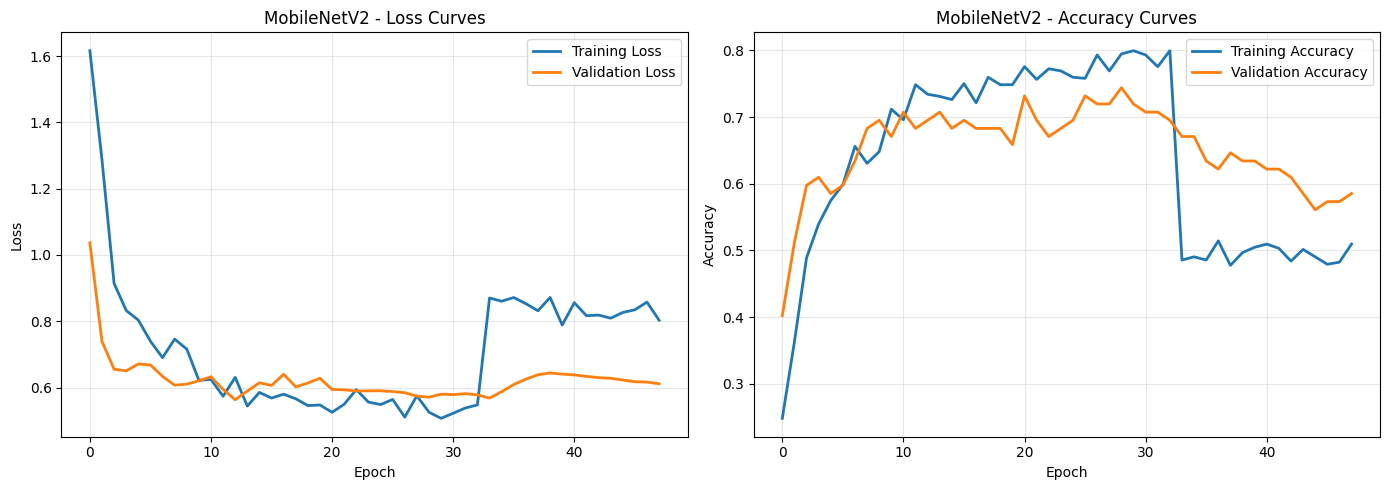

In [51]:
# Plot training history
plot_training_history(mobilenet_history, 'MobileNetV2')

In [52]:
# Evaluate MobileNetV2 with TTA
mobilenet_results = evaluate_model_advanced(
    mobilenet_model, mobilenet_test_gen, mobilenet_preprocess, 'MobileNetV2', use_tta=True
)


EVALUATING MOBILENETV2

Applying Test-Time Augmentation (10 augmentations)...
TTA complete. Averaged 10 predictions.

Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

    diabetic     0.9286    0.5652    0.7027        46
    pressure     0.3636    0.7059    0.4800        34
    surgical     0.8438    0.6429    0.7297        42
      venous     0.8621    0.8065    0.8333        62

    accuracy                         0.6902       184
   macro avg     0.7495    0.6801    0.6864       184
weighted avg     0.7824    0.6902    0.7117       184


Summary Metrics:
------------------------------------------------------------
  Accuracy:  0.6902 (69.02%)
  Precision: 0.7824
  Recall:    0.6902
  F1-Score:  0.7117
  (with TTA: 10 augmentations)


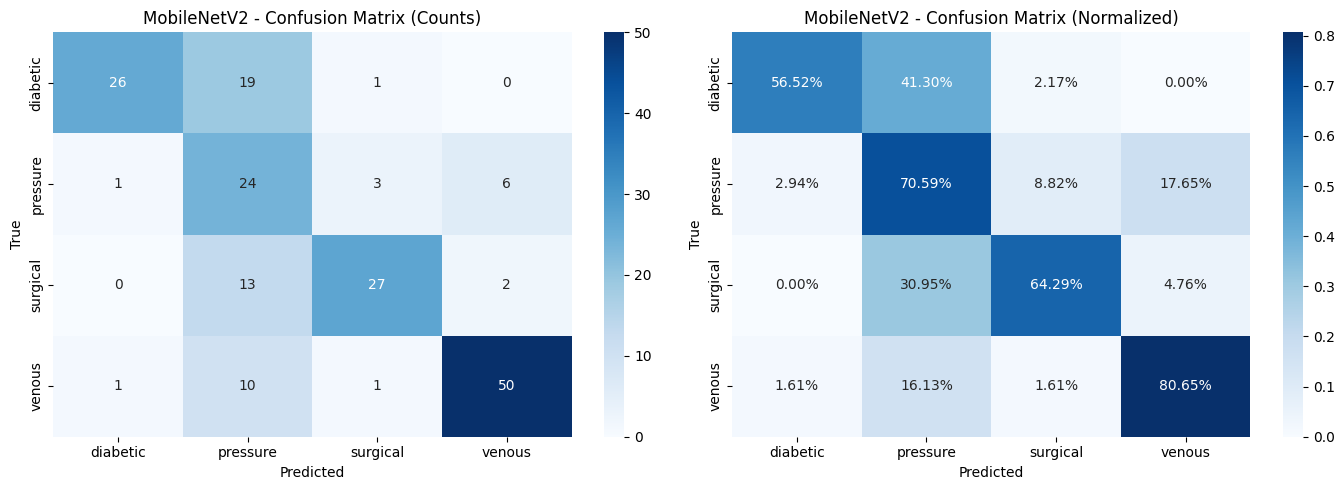

In [53]:
# Plot confusion matrix
plot_confusion_matrix(mobilenet_results, 'MobileNetV2')

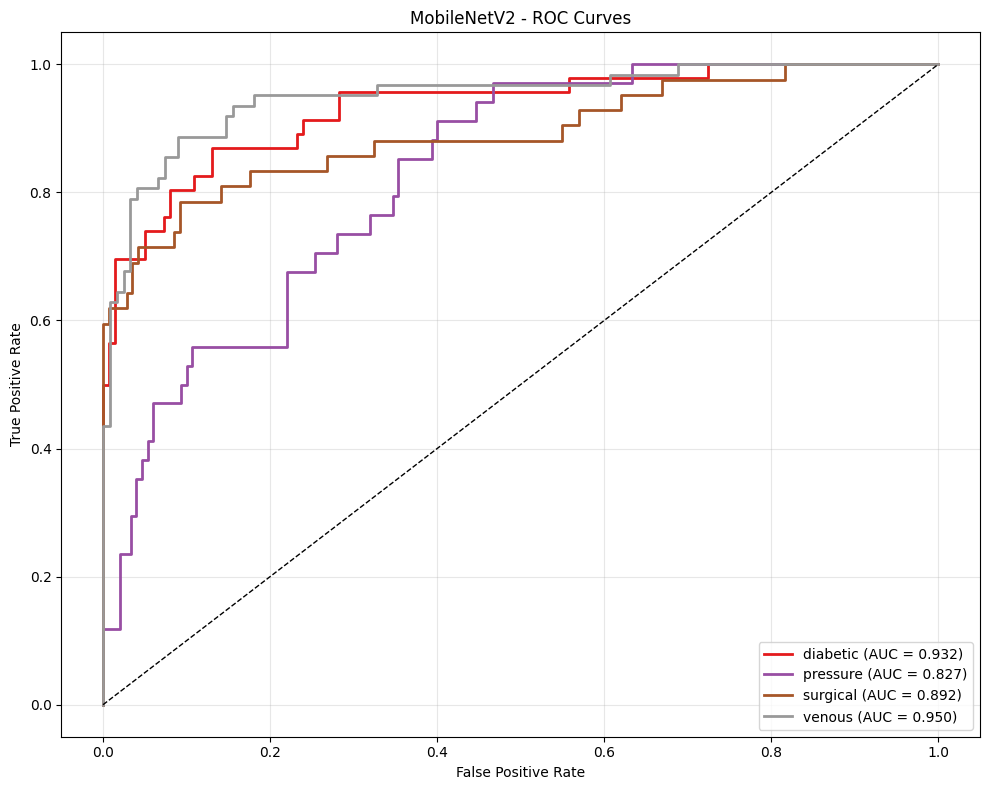

In [54]:
# Plot ROC curves
plot_roc_curves(mobilenet_results, 'MobileNetV2')

## 12. Train EfficientNetB0

In [55]:
# Create generators for EfficientNet
effnet_train_gen, effnet_val_gen, effnet_test_gen, effnet_class_weights = \
    create_advanced_generators('efficientnet')


CREATING ADVANCED GENERATORS FOR EFFICIENTNET
Using EfficientNet preprocessing

Training samples: 464
Validation samples: 82
Test samples: 184

Class distribution and weights:
  diabetic: 118 samples, weight=0.983
  pressure: 85 samples, weight=1.365
  surgical: 104 samples, weight=1.115
  venous: 157 samples, weight=0.739

Oversampling to balance classes (target: 157 per class)
  diabetic: 118 -> 157
  pressure: 85 -> 157
  surgical: 104 -> 157
  venous: 157 (unchanged)
  Total after oversampling: 628

Advanced features enabled:
  - Mixup: True
  - Oversampling: True
  - Training batches per epoch: 40


In [56]:
# Build EfficientNet model
efficientnet_model, efficientnet_base = build_advanced_model('efficientnet')


BUILDING ADVANCED EFFICIENTNET MODEL

Model: efficientnet (Advanced v4)
Total parameters: 4,840,871
Trainable parameters: 789,764


In [57]:
# Train EfficientNet
efficientnet_history = train_advanced_model(
    efficientnet_model, efficientnet_base,
    effnet_train_gen, effnet_val_gen,
    effnet_class_weights,
    model_name='EfficientNetB0'
)


TRAINING EFFICIENTNETB0 (ADVANCED v4)
Using Focal Loss (gamma=3.0, alpha=[np.float64(0.9830508474576272), np.float64(1.3647058823529412), np.float64(1.1153846153846154), np.float64(0.7388535031847133)])

--- PHASE 1: Training classification head ---
Epochs: 40
Learning rate: 0.0005 (with warm-up + cosine decay)
Epoch 1/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.2438 - loss: 1.3557
Epoch 1: val_accuracy improved from -inf to 0.30488, saving model to /content/models/EfficientNetB0_phase1_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 50s 683ms/step - accuracy: 0.2436 - loss: 1.3566 - val_accuracy: 0.3049 - val_loss: 0.7811
Epoch 2/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.3844 - loss: 1.1093
Epoch 2: val_accuracy improved from 0.30488 to 0.51220, saving model to /content/models/EfficientNetB0_phase1_best.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.3850 - loss: 1.1078 - val_accuracy: 0.5122 - val_loss: 0.6366
Epoch 3/40
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 

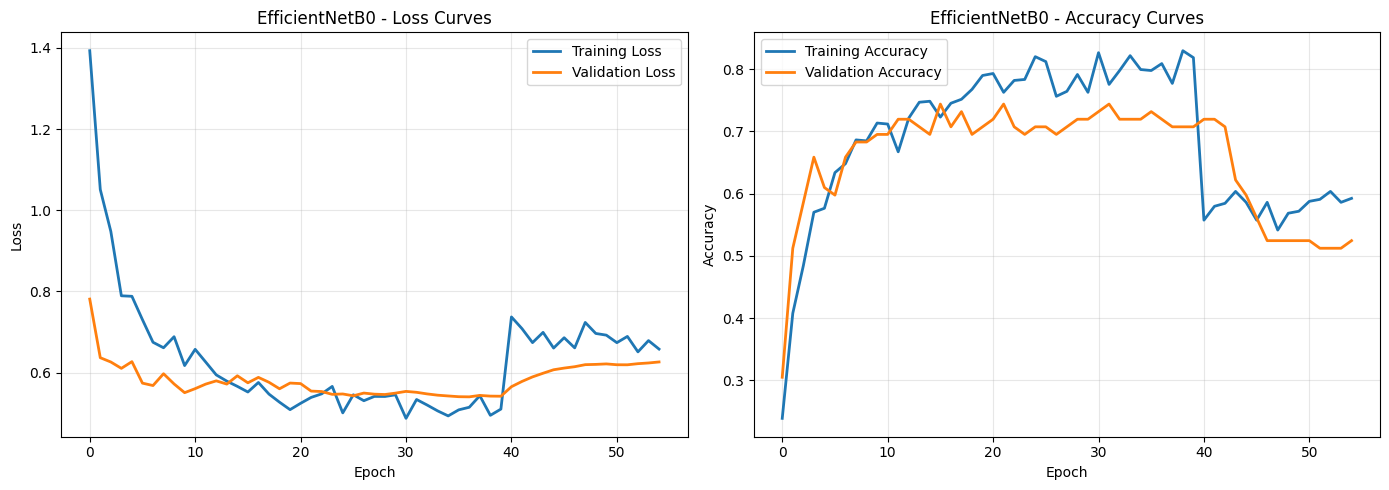

In [58]:
# Plot training history
plot_training_history(efficientnet_history, 'EfficientNetB0')

In [59]:
# Evaluate EfficientNet with TTA
efficientnet_results = evaluate_model_advanced(
    efficientnet_model, effnet_test_gen, efficientnet_preprocess, 'EfficientNetB0', use_tta=True
)


EVALUATING EFFICIENTNETB0

Applying Test-Time Augmentation (10 augmentations)...
TTA complete. Averaged 10 predictions.

Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

    diabetic     0.7955    0.7609    0.7778        46
    pressure     0.7812    0.7353    0.7576        34
    surgical     0.7778    0.8333    0.8046        42
      venous     0.8730    0.8871    0.8800        62

    accuracy                         0.8152       184
   macro avg     0.8069    0.8041    0.8050       184
weighted avg     0.8149    0.8152    0.8146       184


Summary Metrics:
------------------------------------------------------------
  Accuracy:  0.8152 (81.52%)
  Precision: 0.8149
  Recall:    0.8152
  F1-Score:  0.8146
  (with TTA: 10 augmentations)


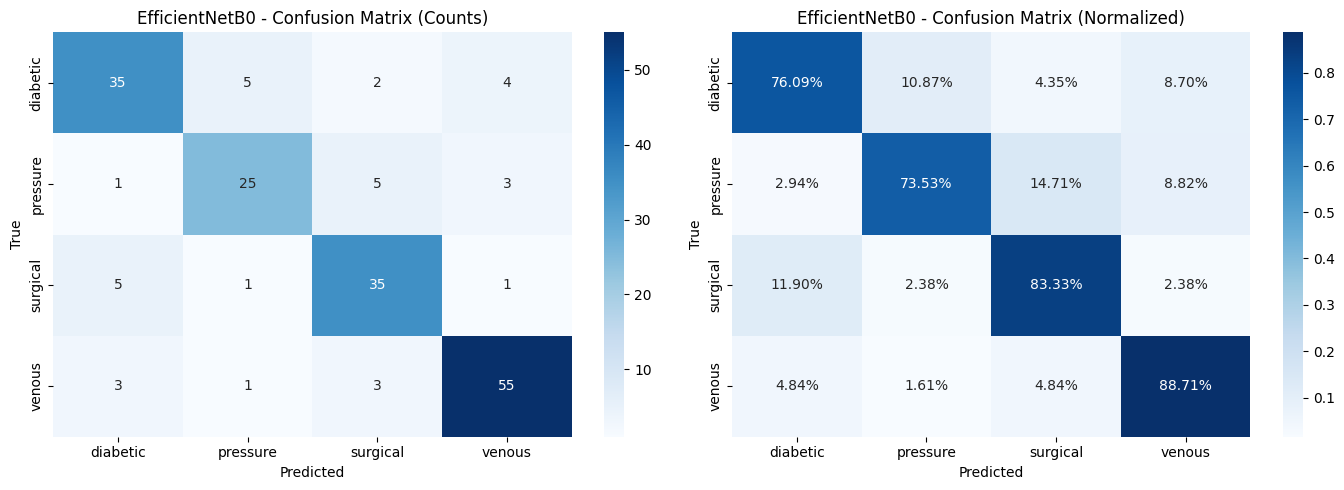

In [60]:
# Plot confusion matrix
plot_confusion_matrix(efficientnet_results, 'EfficientNetB0')

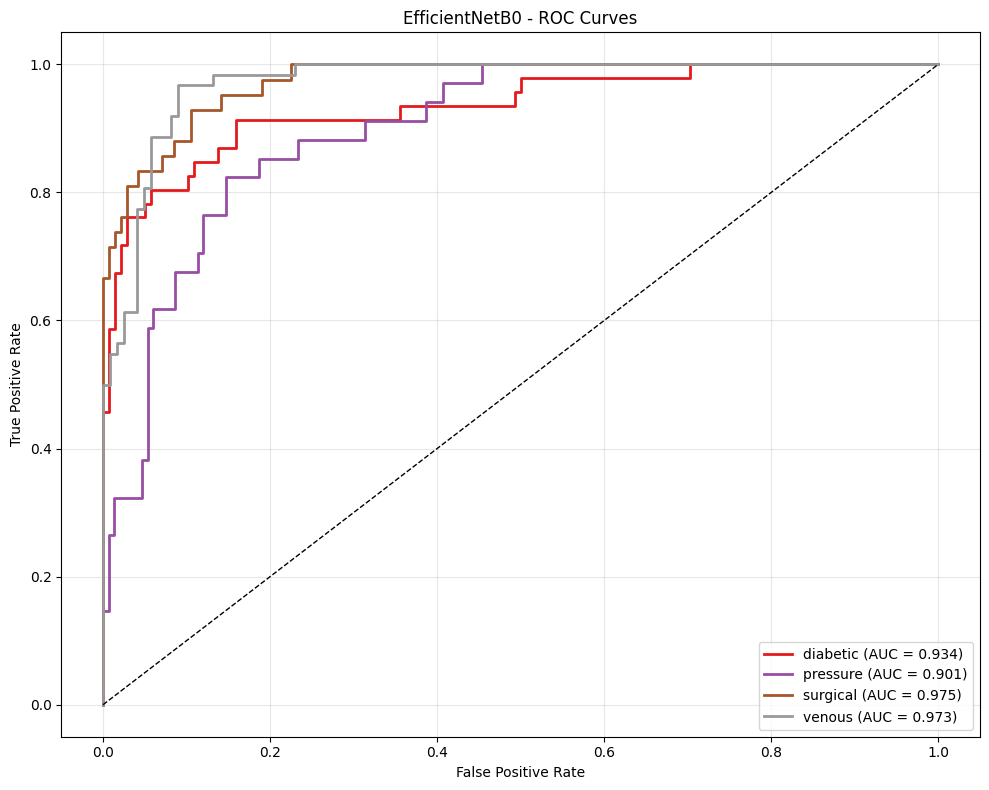

In [61]:
# Plot ROC curves
plot_roc_curves(efficientnet_results, 'EfficientNetB0')

## 13. Ensemble and Final Comparison


ENSEMBLE PREDICTIONS

Combining 2 models with weights: [0.4584837545126354, 0.5415162454873647]
  - MobileNetV2: weight=0.46, accuracy=0.6902
  - EfficientNetB0: weight=0.54, accuracy=0.8152

ENSEMBLE RESULTS
              precision    recall  f1-score   support

    diabetic     0.9091    0.6522    0.7595        46
    pressure     0.5714    0.8235    0.6747        34
    surgical     0.8684    0.7857    0.8250        42
      venous     0.8750    0.9032    0.8889        62

    accuracy                         0.7989       184
   macro avg     0.8060    0.7912    0.7870       184
weighted avg     0.8259    0.7989    0.8024       184


Ensemble Metrics:
------------------------------------------------------------
  Accuracy:  0.7989 (79.89%)
  Precision: 0.8259
  Recall:    0.7989
  F1-Score:  0.8024


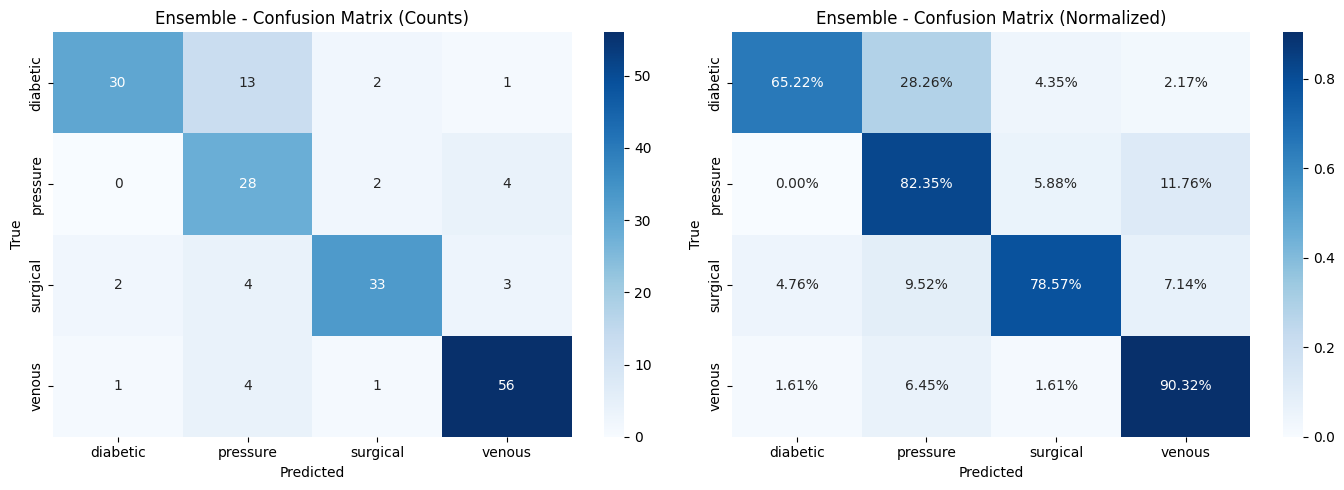

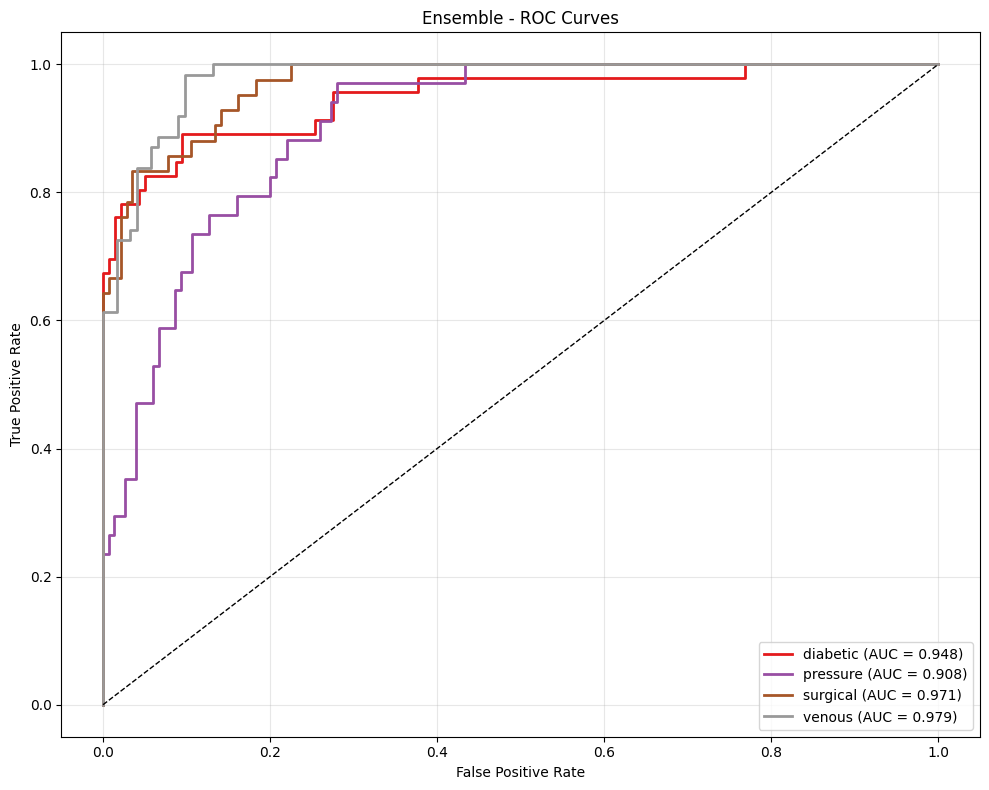

In [62]:
# Create ensemble
if Config.USE_ENSEMBLE:
    # Weight based on individual accuracy
    total_acc = mobilenet_results['accuracy'] + efficientnet_results['accuracy']
    weights = [
        mobilenet_results['accuracy'] / total_acc,
        efficientnet_results['accuracy'] / total_acc
    ]

    ensemble_results = ensemble_predictions(
        [mobilenet_results, efficientnet_results],
        weights=weights
    )

    plot_confusion_matrix(ensemble_results, 'Ensemble')
    plot_roc_curves(ensemble_results, 'Ensemble')


FINAL MODEL COMPARISON

         Model  Accuracy  Precision   Recall  F1-Score
   MobileNetV2  0.690217   0.782411 0.690217  0.711737
EfficientNetB0  0.815217   0.814930 0.815217  0.814611
      Ensemble  0.798913   0.825926 0.798913  0.802378


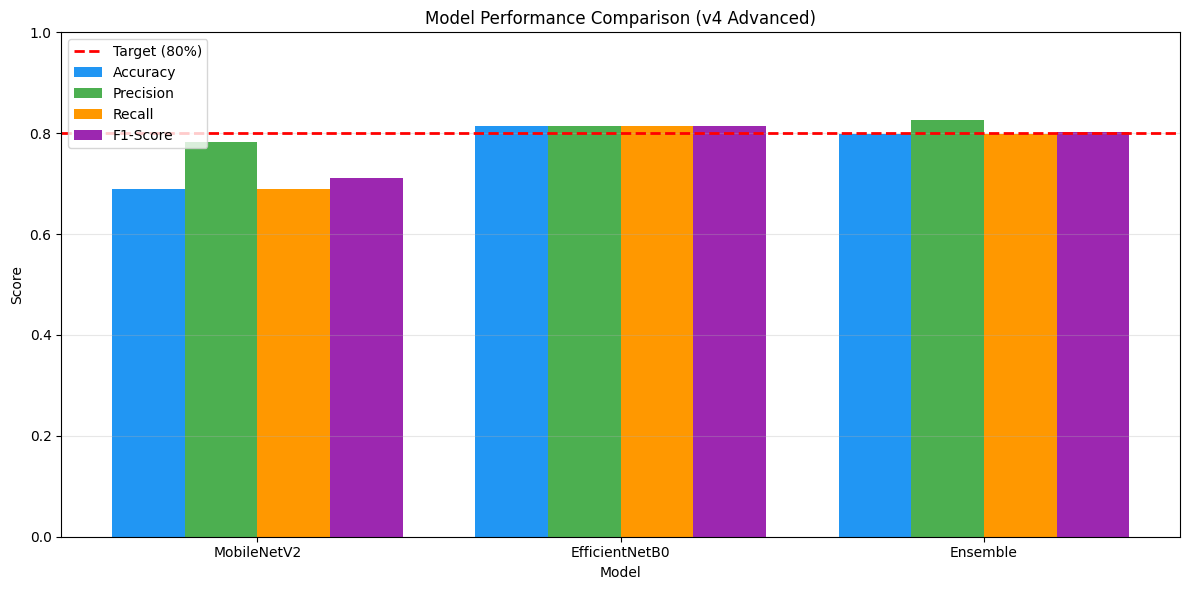


🏆 Best Model: EfficientNetB0 with 81.52% accuracy


In [63]:
# Final comparison
print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

results_list = [mobilenet_results, efficientnet_results]
if Config.USE_ENSEMBLE:
    results_list.append(ensemble_results)

comparison_data = []
for r in results_list:
    comparison_data.append({
        'Model': r['model_name'],
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1-Score': r['f1_score']
    })

df_comparison = pd.DataFrame(comparison_data)
print("\n" + df_comparison.to_string(index=False))

# Save comparison
df_comparison.to_csv(os.path.join(Config.RESULTS_DIR, 'model_comparison_v4.csv'), index=False)

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(df_comparison))
width = 0.2

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, df_comparison[metric], width, label=metric, color=color)

ax.axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='Target (80%)')
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (v4 Advanced)')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_comparison['Model'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'model_comparison_v4.png'), dpi=150)
plt.show()

# Best model
best_idx = df_comparison['Accuracy'].idxmax()
best_model = df_comparison.iloc[best_idx]
print(f"\n🏆 Best Model: {best_model['Model']} with {best_model['Accuracy']*100:.2f}% accuracy")

In [64]:
# Final summary
print("\n" + "=" * 70)
print("PIPELINE EXECUTION COMPLETE - VERSION 4 (ADVANCED)")
print("=" * 70)
print(f"\nResults saved to: {Config.RESULTS_DIR}")
print(f"Models saved to: {Config.MODEL_SAVE_DIR}")

print("\nAdvanced features used:")
print(f"  ✓ Focal Loss: {Config.USE_FOCAL_LOSS}")
print(f"  ✓ Mixup Augmentation: {Config.USE_MIXUP}")
print(f"  ✓ Test-Time Augmentation: {Config.USE_TTA}")
print(f"  ✓ Oversampling: {Config.OVERSAMPLE_MINORITY}")
print(f"  ✓ Ensemble: {Config.USE_ENSEMBLE}")
print(f"  ✓ Warm-up + Cosine Annealing")

print("\nGenerated files:")
for f in sorted(os.listdir(Config.RESULTS_DIR)):
    print(f"  - {f}")


PIPELINE EXECUTION COMPLETE - VERSION 4 (ADVANCED)

Results saved to: /content/results
Models saved to: /content/models

Advanced features used:
  ✓ Focal Loss: True
  ✓ Mixup Augmentation: True
  ✓ Test-Time Augmentation: True
  ✓ Oversampling: True
  ✓ Ensemble: True
  ✓ Warm-up + Cosine Annealing

Generated files:
  - EfficientNetB0_confusion_matrix.png
  - EfficientNetB0_roc_curves.png
  - EfficientNetB0_training_curves.png
  - Ensemble_confusion_matrix.png
  - Ensemble_roc_curves.png
  - MobileNetV2_confusion_matrix.png
  - MobileNetV2_roc_curves.png
  - MobileNetV2_training_curves.png
  - model_comparison_v4.csv
  - model_comparison_v4.png


## 14. Download Results

In [67]:
# Zip and download
!zip -r /content/wound_classification_results_v4.zip {Config.RESULTS_DIR} {Config.MODEL_SAVE_DIR} {Config.DATA_DIR}/dataset_metadata.csv

from google.colab import files
files.download('/content/wound_classification_results_v4.zip')

updating: content/results/ (stored 0%)
updating: content/results/model_comparison_v4.csv (deflated 44%)
updating: content/results/Ensemble_roc_curves.png (deflated 18%)
updating: content/results/MobileNetV2_roc_curves.png (deflated 18%)
updating: content/results/MobileNetV2_confusion_matrix.png (deflated 11%)
updating: content/results/EfficientNetB0_confusion_matrix.png (deflated 12%)
updating: content/results/EfficientNetB0_roc_curves.png (deflated 18%)
updating: content/results/MobileNetV2_training_curves.png (deflated 7%)
updating: content/results/model_comparison_v4.png (deflated 24%)
updating: content/results/Ensemble_confusion_matrix.png (deflated 11%)
updating: content/results/EfficientNetB0_training_curves.png (deflated 7%)
updating: content/models/ (stored 0%)
updating: content/models/MobileNetV2_final.keras (deflated 10%)
updating: content/models/EfficientNetB0_phase1_best.keras (deflated 11%)
updating: content/models/MobileNetV2_phase1_best.keras (deflated 10%)
updating: con

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>